# Spatio-Temporal Forecasting of Elk and Pronghorn Wildlife-Vehicle Collisions (WVC) along Arizona Highway Corridors

**Name:** Great Gilbert Soco (26002404850)\
**Date:** 5/28/2026

# Spatio-Temporal Forecasting of Wildlife-Vehicle Collisions: A Multimodal Mixed-Model Approach for Arizona Highway Corridors

---

## 1. Research Foundation

### 1.1 Research Context & Motivation
In the statre of Arizona, transportation corridors, such as the Interstate 40 (I-40) and State Rout 260 (SR-260) cut directly through the native migratory ranges of animals, specifically elk and pronghorn. The result is a high frequency of safety-critical traffic incidents that cause significant property damage, ecological disruption, and human injuries and death. These incidents, known as Wildlife Vehicle Collisions (WVCs) represent a critical intersection between public safety, infrastructure resilience, and wildlife conservation.

Traditional approachs to transportation safety mapping relies heavily on past spatial density aggregation that focus more on static hotspot mapping of past WVCs rather than dynamic forecasting [1]. The nature of WVCs feature highly dynamic, temporal fluctations driven by various factors. These factors include human commuting cycles, changing seasonal conditions, and active wildlife migration waves. Traditional methods often fail to account for the highly dynamic nature of WVCs. To bridge this gap, this project reframes WVC mitigation as a dynamic spatio-temporal forecasting problem. By regularizing discrete accident logs into continuous spatial-temporal grids, this research aims to leverage deep learning architectures to predict localized risk horizons before collisions occur.

### 1.2 Research Question
To what extent can advanced machine learning architectures leverage a combination of historical accident sequences, seasonal human traffic variables, and exogenous biological tracking data to predict short-term Wildlife-Vehicle Collisions (WVC)? 

Specifically, how does a **univariate autoregressive model** (relying solely on historical crash logs to establish a performance baseline) compare against a **multivariate mixed-model fusion framework** that integrates the real-time migratory telemetry of elk and pronghorn across a distributed highway corridor network?

### 1.3 Methodological Scope & Modeling Paradigms
This study evaluates and benchmarks predictive performance across two distinct sections, explicitly differentiating between statistical scopes and spatial dimensions:

1. **Part 1: Univariate Autoregressive Modeling (The Baseline Floor)**
   * **Data Dimension:** Features are strictly limited to historical WVC event sequences and deterministic temporal vectors (cyclical calendar variations).
   * **Spatial Scope (Single-Point vs. Multi-Point):** This section contrasts traditional statistical forecasting with introductory deep learning. 
     * *Single-Point Scope:* Traditional models (Naïve, Moving Average, and Seasonal ARIMA) are trained on an isolated, high-density hazard segment (Segment 0) to evaluate local temporal patterns.
     * *Multi-Point Scope:* Baseline neural networks (Multi-Headed MLPs and 1D Convolutional Neural Networks) ingest the entire highway network simultaneously, assessing parallel spatial channels to identify broader trends across all 96 segments.
   * **Objective:** Establish a rigorous baseline performance floor to quantify how much predictive value can be extracted from historical crash trends alone.

2. **Part 2: Multivariate Mixed-Model Fusion (The Ecological Expansion)**
   * **Data Dimension:** Transitions from a pure time-series format to a multimodal mixed model. It fuses historical transportation records with real-time exogenous environmental features and spatialized USGS GPS-collar telemetry data tracking active ungulate migration waves.
   * **Spatial Scope (Multi-Point Network):** Full parallel channel processing across all 96 spatial corridors simultaneously.
   * **Objective:** Capture the non-linear, environmental catalysts of wildlife movement, transitioning the pipeline from a reactive historical log tracker into a proactive, ecologically grounded risk mitigation engine.

### 1.4 Engineering Justification
Modeling highway safety data presents a severe mathematical challenge: **extreme data sparsity**. Because accidents are safety-critical anomalies, the resulting daily matrix is highly zero-inflated (typically >95% zero values). Traditional statistical time-series models hit a structural ceiling here because they assume a continuous, linear Gaussian error distribution. 

By scaling to a multi-input, deep learning framework using **Long Short-Term Memory (LSTM)** networks, we introduce specialized memory gates capable of tracking temporal momentum across a lookback window. When fused with real-time biological telemetry vectors, the network can map ecological triggers directly onto specific spatial highway segments, bypassing the sparsity bottleneck and anticipating sudden crossing spikes.

### 1.5 Notebook Pipeline Architecture
To maintain maximum reproducibility and analytical clarity, the notebook is structured into the following operational phases:
* **Section 2: Exploratory Data Analysis & Spatial Matrix Engineering** – Aggregating point-event incident logs into a regularized daily 5-mile linear referencing matrix and quantifying global sparsity.
* **Section 3: Cyclical Feature Extraction** – Transforming calendar dates into non-linear temporal coordinates using sin/cos transformations.
* **Section 4: Part 1 - Univariate Benchmarking** – Implementing single-point statistical baselines (Naïve, MA, SARIMA) and multi-point baseline networks (MLP, 1D-CNN, Simple RNN).
* **Section 5: Part 2 - Multivariate Spatio-Temporal Fusion** – Processing USGS telemetry streams and training a multi-headed Ecological-Fusion LSTM.
* **Section 6: Applied Informatics & Infrastructure Synthesis** – Comparative performance tables, model validation analysis, and operational recommendations for dynamic highway warning deployments.

## 2. Exploratory Data Analysis & Spatial Matrix Engineering

### 2.1 Spatial Discretization & Grid Formulation
The dataset used in this project consist of coordinate-based incident points. Therefore, in order to make this data compatible with deep learning tensors, linear spatial discreitization must be applied. A 2d grid where the temporal dimension is discretized daily ($\Delta t = 1 \text{ day}$) and the linear highway distance is partitioned into equal, non-overlapping spatial bins ($\Delta x = 5 \text{ miles}$).

Let $C_i = (t_i, x_i)$ represent an individual collision event occurring at timestamp $t_i$ and linear milepost $x_i$. The mapping function $f(x_i)$ assigns each event to a discrete spatial channel index $j$:

$$j = \left\lfloor \frac{x_i}{\Delta x} \right\rfloor$$

For a network of total length $L$, the number of spatial segments is bounded by $N = \lceil L / \Delta x \rceil$. The intersection of all daily time steps $T$ and spatial channels $N$ forms our master observation matrix $\mathbf{M} \in \mathbb{R}^{T \times N}$, where each element $M_{t,j}$ represents the total incident count for day $t$ within segment $j$.

### 2.2 Quantifying the Sparsity Bottleneck
A fundamental property of safety-critical event forecasting is extreme zero-inflation. This is due to the fact that these accidents are rare events relative to everyday. As such, the majority of cells in $\mathbf{M}$ will equal zero. We formally quantify the network sparsity $S$ as:

$$S = \left( 1 - \frac{\sum_{t=1}^{T} \sum_{j=0}^{N-1} \mathbb{I}(M_{t,j} > 0)}{T \times N} \right) \times 100\%$$

Where $\mathbb{I}$ is the indicator function. High sparsity ($S > 90\%$) creates severe challenges for standard loss functions like Mean Squared Error (MSE), as models can achieve low global error by simply predicting zero everywhere. This architectural bottleneck justifies the subsequent shift toward gated memory structures (LSTMs) and ecological feature fusion to force the network to identify localized risk states.

### 2.3 Spatial Hotspots and Temporal Timeline Plots

An important aspect of data analysis is to visualize the timeseries data in order to identify trends, seasons, and cycles. Visualization is also helpful in identifying particular instances, such as outliers, where the value may differ from the established patterns. This is most helpful in this problem because WVCs depend on highly dynamic data.

In [9]:
#
# 2.1 Data Engineering Pipeline: From Raw Logs to Regularized Time Series Matrix
#
# 2.2 Quantifying Sparsity and Identifying Hotspots in the WVC Time Series Matrix
#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

import warnings
warnings.filterwarnings('ignore')

# Loading and Filtering ADOT Data
def load_and_filter_adot_data(file_path):
    """
    Ingests the raw ADOT dataset, parses date/time signatures, and filters
    strictly for Wildlife-Vehicle Collisions (WVC) using standardized event codes.
    """
    df = pd.read_csv(file_path)

    # Parse explicit datetime formats safely
    df['Crash_DateTime'] = pd.to_datetime(
        df['IncidentDateTime'], 
        format="%m/%d/%Y %I:%M:%S %p", 
        errors='coerce'
    )
    df['Date'] = df['Crash_DateTime'].dt.normalize()
    
    # Filter for target wildlife indicators: Code 21.0 (Wild Non-Game), Code 22.0 (Wild Game)
    wvc_df = df[df['FirstHarmfulEvent'].isin([21.0, 22.0])].copy()
    
    wvc_df = wvc_df.dropna(subset=['MPNum', 'Date']) # Discard records with missing milepost or date information
    
    return wvc_df

# Constructing the Master Time Series Matrix
def build_master_time_series(wvc_df, freq='D', spatial_resolution_miles=5):
    """
    Transforms point logs into a continuous, regularized (Time x Segment) matrix.
    Ensures complete space-time boundaries for the full calendar year.
    """
    

    wvc_df['Segment'] = (wvc_df['MPNum'] // spatial_resolution_miles) * spatial_resolution_miles # Bins mileposts into defined spatial segments
    all_dates = pd.date_range(start='2021-01-01', end='2021-12-31', freq=freq)
    all_segments = sorted(wvc_df['Segment'].unique())
    
    multi_index = pd.MultiIndex.from_product([all_dates, all_segments], names=['Date', 'Segment'])

    master_grid = pd.DataFrame(index=multi_index).reset_index()
    
    counts = wvc_df.groupby(['Date', 'Segment']).size().reset_index(name='Crash_Count')
    
    # Merge event metrics into the master spatial-temporal grid
    master_df = pd.merge(master_grid, counts, on=['Date', 'Segment'], how='left')
    master_df['Crash_Count'] = master_df['Crash_Count'].fillna(0).astype(int)
    
    # Feature Engineering: Extract base temporal features for later multi-input models
    master_df['DayOfWeek'] = master_df['Date'].dt.dayofweek
    master_df['Month'] = master_df['Date'].dt.month
    master_df['Month_Sin'] = np.sin(2 * np.pi * master_df['Month']/12.0)
    master_df['Month_Cos'] = np.cos(2 * np.pi * master_df['Month']/12.0)
    
    # Set to standard wide time-series matrix: Rows = Days, Columns = Spatial Mile Bins
    ts_matrix = master_df.pivot(index='Date', columns='Segment', values='Crash_Count').fillna(0)
    
    return master_df, ts_matrix

# Pipeline Execution
adot_file_path = r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\2021_Crash_Data\2021 Crash Data\Incident_2021.csv"

wvc_data = load_and_filter_adot_data(adot_file_path)
master_flat_df, time_series_matrix = build_master_time_series(wvc_data, freq='D', spatial_resolution_miles=5)

# Sparsity Auditing and Hotspot Identification
total_cells = time_series_matrix.size
zero_cells = (time_series_matrix == 0).sum().sum()
global_sparsity = (zero_cells / total_cells) * 100

segment_totals = time_series_matrix.sum(axis=0).sort_values(ascending=False)

print("="*65)
print("         DATA ENGINEERING PIPELINE DIAGNOSTICS          ")
print("="*65)
print(f"[+] Total Filtered WVC Incident Points Ingested    : {len(wvc_data)}")
print(f"[+] Master Matrix Dimensions (Days × Spatial Bins)  : {time_series_matrix.shape}")
print(f"[+] Total Spatio-Temporal Intersections Evaluated  : {total_cells}")
print(f"[+] Calculated Global Matrix Sparsity Metric       : {global_sparsity:.2f}%")
print("-"*65)
print("TOP 5 PRIMARY HAZARD CORRIDORS (CRASH COUNT DENSITY):")
for rank, (seg_id, count) in enumerate(segment_totals.head(5).items(), 1):
    print(f"  Rank {rank}: Milepost Segment {seg_id:03d} -> Total Historical Crashes: {int(count)}")
print("="*65)

         DATA ENGINEERING PIPELINE DIAGNOSTICS          
[+] Total Filtered WVC Incident Points Ingested    : 1836
[+] Master Matrix Dimensions (Days × Spatial Bins)  : (365, 96)
[+] Total Spatio-Temporal Intersections Evaluated  : 35040
[+] Calculated Global Matrix Sparsity Metric       : 95.69%
-----------------------------------------------------------------
TOP 5 PRIMARY HAZARD CORRIDORS (CRASH COUNT DENSITY):
  Rank 1: Milepost Segment 000 -> Total Historical Crashes: 553
  Rank 2: Milepost Segment 330 -> Total Historical Crashes: 42
  Rank 3: Milepost Segment 290 -> Total Historical Crashes: 39
  Rank 4: Milepost Segment 345 -> Total Historical Crashes: 39
  Rank 5: Milepost Segment 315 -> Total Historical Crashes: 35


#### Post-Analysis Reflection:
The output of the previous cell highlighted the main challenge of the dataset. The results show a calculated matrix sparsity of 95.69%, which makes sense given the nature that even on segments with a high-risk for WVCs, these events are relatively rare. High mathematical sparsity invalidates standard Gaussian error distribution assumptions, meaning classic MSE evaluation might be heavily skewed by the overwhelming presence of zero values.

A noticeable feature to also point out is the extreme collision density observed at Milepost Segment 000. Milepost Segment 000 represents classic spatiotemporal bottlenec driven by the intersection of landscape ecology and linear transportation infrastructure: 

* **Seasonal Elevational Migration:** In northern and central Arizona, the I-40 and SR-260 corridors cut perpendicularly through the historical migratory pathways of Rocky Mountain elk and pronghorn. Every year, elk and pronghorn migrate between high-altitude forested summer ranges and arid winter basins. Geographic features like ridges funnel moving herds. This indicates that Segment 000 perhaps directly intersects an important landscpae corridor for these migrations. 

* **The Fencing Barrier Effect:** While elk possess the physical capacity to clear standard right-of-way (ROW) wildlife fences, pronghorn characteristically refuse to jump vertical barriers, preferring to navigate under the bottom wire. [2] Therefore, for pronghorn herds, this behavior forces them to wander parallel to the highway infrastructure until there is a crossing point where the fencing breaks or the land flattens.


* **Micro-Climatic Micro-Environments:** Elk and pronghorn can be seasonally sighted on the roadside. This is due to the fact that roadside veergess beenfit from localized water runoff. This resuls in prolonged vegetation greenness and enhanced forage quality compared to the surrounding arid interior. [3] This often draws large elk and pronghorn populations to the side of the highway, increasing collision risk. 


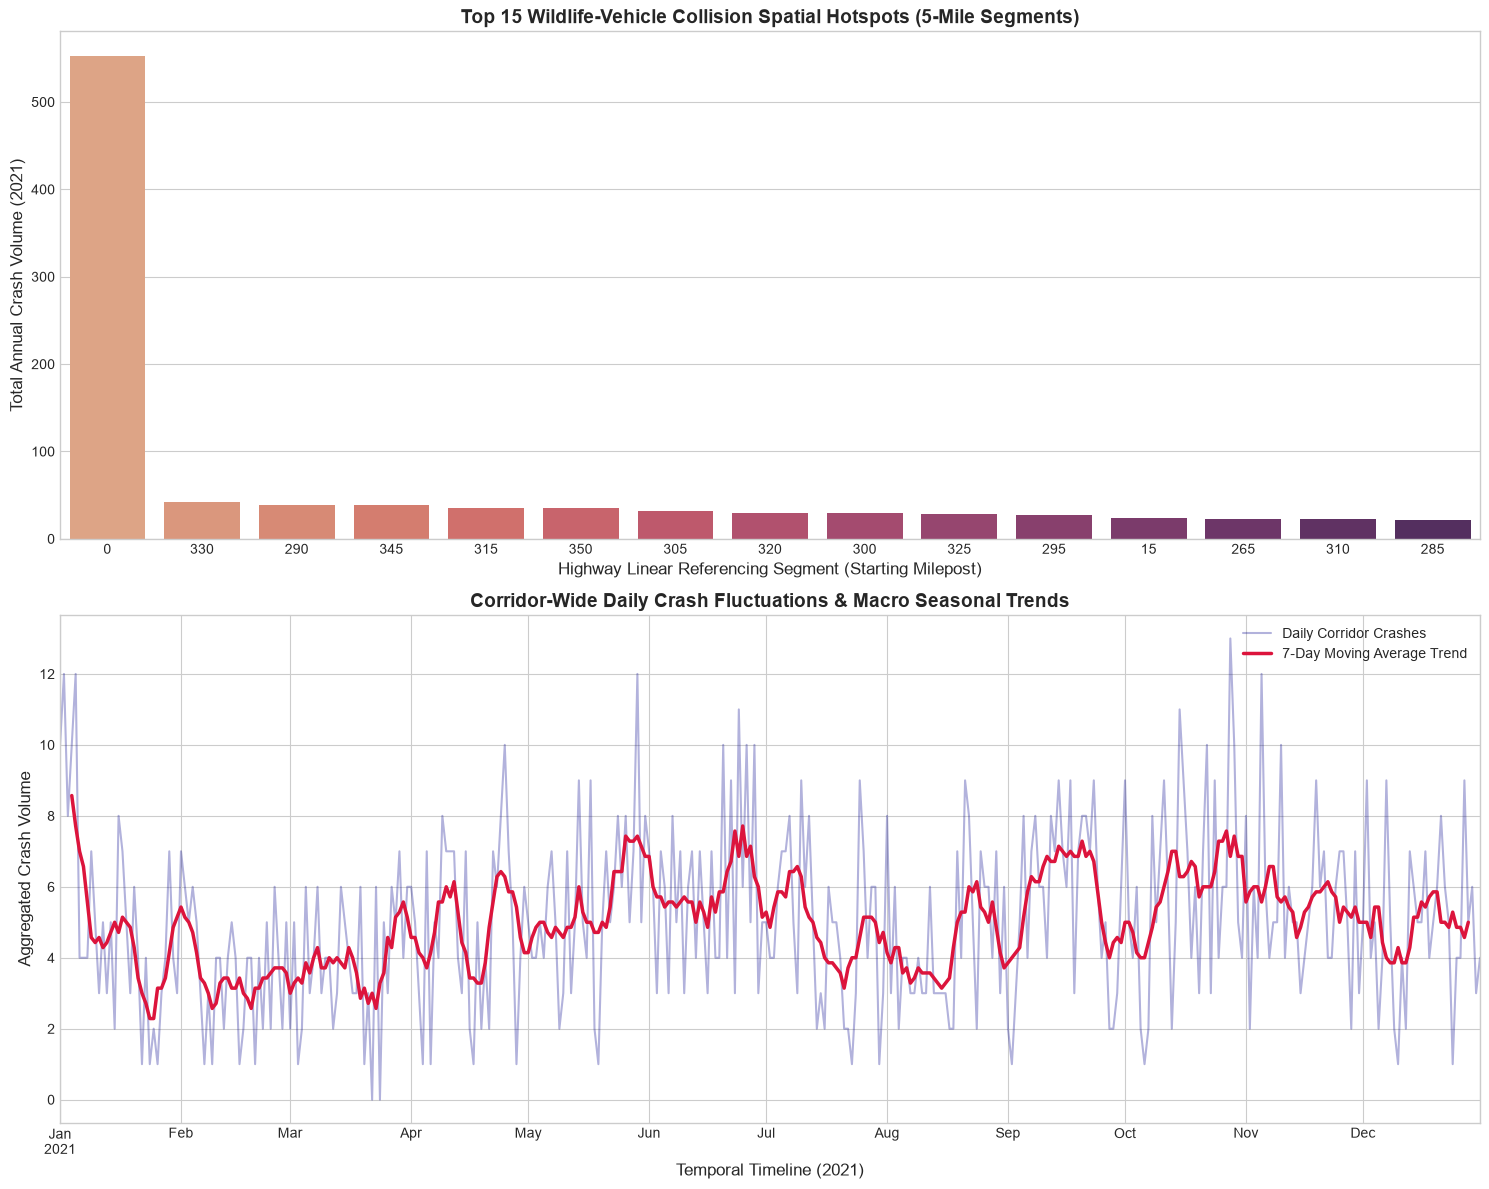

In [10]:
# 2.3 Generate Spatial Hotspots and Temporal Timeline Plots
#
# The Spatial Hotspots plot identifies the top 15 highway segments with the highest total crash volumes in 2021, highlighting critical areas for targeted interventions. 
# 
# The Temporal Timeline plot illustrates daily crash fluctuations across the entire corridor, overlaid with a 7-day moving average to reveal macro seasonal trends and 
# potential periods of heightened risk.
#

spatial_totals = time_series_matrix.sum().sort_values(ascending=False)
top_segments = spatial_totals.head(15)

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Spatial Hotspots
sns.barplot(x=top_segments.index, y=top_segments.values, ax=axes[0], palette='flare', order=top_segments.index)
axes[0].set_title('Top 15 Wildlife-Vehicle Collision Spatial Hotspots (5-Mile Segments)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Highway Linear Referencing Segment (Starting Milepost)', fontsize=12)
axes[0].set_ylabel('Total Annual Crash Volume (2021)', fontsize=12)

# Plot 2: Macro Temporal Timeline Corridor-wide
daily_corridor_totals = time_series_matrix.sum(axis=1)
daily_corridor_totals.plot(ax=axes[1], color='darkblue', alpha=0.3, label='Daily Corridor Crashes')
daily_corridor_totals.rolling(window=7, center=True).mean().plot(
    ax=axes[1], color='crimson', linewidth=2.5, label='7-Day Moving Average Trend' # 7-day moving average to smooth out daily fluctuations and reveal underlying trends
)
axes[1].set_title('Corridor-Wide Daily Crash Fluctuations & Macro Seasonal Trends', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Temporal Timeline (2021)', fontsize=12)
axes[1].set_ylabel('Aggregated Crash Volume', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Post-Analysis Reflection

Plot 1 isolates the top 15 road segments with the highest Wildlife-Vehicle Collision (WVC) counts, highlighting Segment 000 as the most hazardous corridor. To understand when these incidents occur, Plot 2 visualizes the temporal distribution of WVCs across all segments. 

The data reveals that January experience the absolute highest volume of collisions, driven by a combination of biological and environmental factors:

* **Diminished Food Availability:** Severe winter conditions deplete natural resources, forcing wildlife to travel longer distances and frequently cross major highways in search of forage.
* **Reduced Visibility and Commute Overlap:** Because Arizona does not observe Daylight Saving Time, winter standard time shifts sunset earlier into the evening. This creates a dangerous overlap between peak rush-hour traffic and peak crepuscular wildlife activity at dusk.
* **Winter Tourism Surge:** January is a peak travel month in Arizona. Increased motorist density on rural highways—particularly travelers heading to high-country winter vacation spots—statistically raises the probability of vehicle-wildlife encounters.

Following the January peak, the data shows a sharp drop in February before climbing again into the spring. This short-term dip is heavily tied to winter weather dynamics; heavy mid-winter snowpack temporarily locks herds into low-elevation wintering grounds, minimizing their daily movements and road crossings until conditions shift.

As the year progresses, WVC patterns continue to fluctuate based on seasonal behaviors:

* **March to Mid-July Rise:** Rising temperatures and dry spring conditions force wildlife to travel extensively to find scarce water and fresh forage, driving up highway crossings.
* **August Drop:** The onset of summer monsoons replenishes water sources and vegetation at higher elevations, allowing animals to forage safely without migrating across roads.
* **August to October Spike:** This period marks the wildlife "rut" (breeding season), leaving animals highly distracted, active, and prone to traveling long distances.
* **October Drop:** The commencement of rifle hunting season pushes wildlife away from open road corridors and deep into heavy forest cover to evade hunters.
* **Post-November Decline:** Dropping late-autumn temperatures and early snow push herds back into stable winter ranges, lowering encounters before the cycle resets.

## 3. Cyclical Feature Extraction

### 3.1 The Limits of Linear Temporal Representations
The problem with building an effective forecasting model is that the neural networks must have a clear understanding of human calendar cycles. However, representing temporal variables like hours (0–23), days of the week (0–6), or months (1–12) as raw, linear integers introduces a critical mathematical flaw.If we represent the month of December as `12` and January as `1`, a neural network using standard distance-based weight updates will interpret these two time periods as being 11 units apart. In reality, January 1 immediately follows December 31. These dates are chronologically adjacent. This artificial numerical discontinuity severely degrades a model's ability to recognize smooth, cyclical patterns.

### 3.2 Trigonometric Coordinate Projection
To fix this distance assumption error, we project linear temporal features into a two-dimensional continuous space using sine and cosine transformations. This maps each time step onto a unit circle, allowing to preserve true temporal proximity. 

The cyclical transformations for the monthly cycle are defined mathematically as:

$$\mathbf{X}_{\sin} = \sin\left(\frac{2 \pi \cdot m}{M}\right), \quad \mathbf{X}_{\cos} = \cos\left(\frac{2 \pi \cdot m}{M}\right)$$

Where $m$ is the linear month index and $M = 12$ represents the total period length. Under this transformation, December ($\sin \approx -0.5, \cos \approx 0.866$) and January ($\sin \approx 0.5, \cos \approx 0.866$) sit perfectly adjacent to one another in Euclidean feature space, allowing our downstream multi-headed networks to accurately map calendar-based traffic and migration patterns.

         TEMPORAL FEATURE ENGINEERING DIAGNOSTICS        
SAMPLE OF TRANSFORMED CYCLICAL COORDINATES:
      Date  Month  Month_Sin  Month_Cos
2021-01-01      1        0.5   0.866025
2021-01-02      1        0.5   0.866025
2021-01-03      1        0.5   0.866025
2021-01-04      1        0.5   0.866025
2021-01-05      1        0.5   0.866025
-----------------------------------------------------------------
      Date  Month     Month_Sin  Month_Cos
2021-12-27     12 -2.449294e-16        1.0
2021-12-28     12 -2.449294e-16        1.0
2021-12-29     12 -2.449294e-16        1.0
2021-12-30     12 -2.449294e-16        1.0
2021-12-31     12 -2.449294e-16        1.0


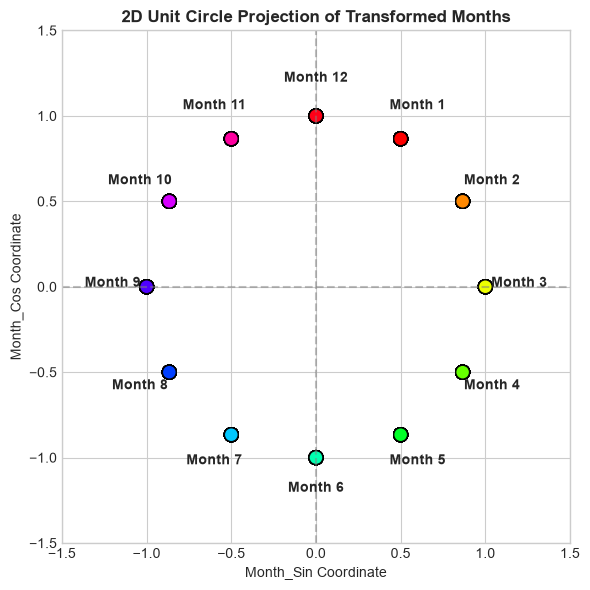

In [ ]:
#
# 3.1 and 3.2 Engineering Validation: Verifying Cyclical Feature Transformations
#

def verify_and_plot_cyclical_features(flat_df):
    """
    Isolates the engineered calendar features from the master dataframe,
    verifies their geometric boundaries, and plots their cyclical nature.
    """
    
    # Extract unique chronological dates to evaluate the calendar features
    unique_calendar = flat_df.drop_duplicates(subset=['Date']).sort_values('Date').copy()
    
    print("="*65)
    print("         TEMPORAL FEATURE ENGINEERING DIAGNOSTICS        ")
    print("="*65)
    print("SAMPLE OF TRANSFORMED CYCLICAL COORDINATES:")
    print(unique_calendar[['Date', 'Month', 'Month_Sin', 'Month_Cos']].head(5).to_string(index=False))
    print("-"*65)
    print(unique_calendar[['Date', 'Month', 'Month_Sin', 'Month_Cos']].tail(5).to_string(index=False))
    print("="*65)
    
    # Generate a verification scatter plot to confirm the unit circle projection
    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter(unique_calendar['Month_Sin'], unique_calendar['Month_Cos'], 
                         c=unique_calendar['Month'], cmap='hsv', edgecolor='k', s=100)
    
    # Annotate the months to visually confirm continuity
    for i, month in enumerate(unique_calendar['Month'].unique()):
        sample_row = unique_calendar[unique_calendar['Month'] == month].iloc[0]
        ax.text(sample_row['Month_Sin']*1.2, sample_row['Month_Cos']*1.2, 
                f"Month {int(month)}", fontsize=10, weight='bold', ha='center')
                
    ax.set_title("2D Unit Circle Projection of Transformed Months", fontsize=12, weight='bold')
    ax.set_xlabel("Month_Sin Coordinate")
    ax.set_ylabel("Month_Cos Coordinate")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.axvline(0, color='grey', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


verify_and_plot_cyclical_features(master_flat_df)

## 4. Part 1 - Univariate Benchmarking & Single-Point Baselines

### 4.1 The Modeling Scope Matrix: Single-Point vs. Multi-Point
Before deploying high-capacity deep learning models across the entire distributed highway network, a statistical performance floor must be established. Therefore, evaluation will be split into the two distinct dimensions: 

1. **Single-Point Modeling (Localized Autoregression):** Traditional statistical time-series models (such as Naïve drift models, Moving Averages, and seasonal ARIMA) are mathematically built to handle a single, continuous, one-dimensional vector. We isolate our highest-density hazard corridor (**Milepost Segment 0**) to evaluate these traditional baselines under optimal conditions where data sparsity is minimized.

2. **Multi-Point Modeling (Distributed Spatial Channels):** Modern neural networks handle multi-dimensional arrays. In the next phase, architectures like Multi-Headed MLPs, 1D-CNNs, and RNNs will ingest all 96 parallel spatial segments simultaneously, treating the highway network as an interconnected system.

For each model, the MAE and RMSE will be evaluated. This is because MAE allows us to determine which model has the lowest average forecast error and RMSE which model makes fewer large forecasting mistakes.

### 4.2 Sliding Window Formulation & Train/Test Stratification
To evaluate our models effectively, we transform our continuous daily time-series vector into fixed structural slices using a sliding window technique. 

Let $x_t$ represent the collision count on Day $t$ for a given segment. Given a lookback window length of $L = 14 \text{ days}$ and a forward predictive hazard horizon of $H = 3 \text{ days}$, each training sample consists of:
* **Input Feature Vector ($\mathbf{X}$):** $[x_{t-L+1}, x_{t-L+2}, \dots, x_t] \in \mathbb{R}^{14}$
* **Target Truth Vector ($\mathbf{Y}$):** $[x_{t+1}, x_{t+2}, \dots, x_{t+H}] \in \mathbb{R}^3$

To maintain chronological data integrity and prevent data leakage, we reject randomized cross-validation. This is because we are working with time series data, meaning it does not make any sense to shuffle the data around.  Therefore, a strict **temporal train/test split** is enforced. The first 80% of consecutive calendar days are reserved exclusively for model optimization and parameter estimation, while the final 20% of the year serves as our out-of-sample validation testing phase.

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Isolate the primary hotspot corridor (Segment 0) for univariate forecasting validation
seg0_series = time_series_matrix[0].values
total_days = len(seg0_series)

# Determine chronological split boundary (80% Train, 20% Test)
split_idx = int(total_days * 0.80)
train_series = seg0_series[:split_idx]
test_series = seg0_series[split_idx:]

# Define operational windows
lookback = 14
horizon = 3

# Generate the sliding windows for the test partition
X_test_windows = []
y_true_windows = []

# Construct windows out of the test partition
for i in range(len(test_series) - lookback - horizon + 1):
    X_test_windows.append(test_series[i : i + lookback])
    y_true_windows.append(test_series[i + lookback : i + lookback + horizon])

X_test_windows = np.array(X_test_windows)
y_true_flat = np.array(y_true_windows).flatten()

print("="*65)
print("         SINGLE-POINT WINDOW TIMELINE GENERATED          ")
print("="*65)
print(f"Total Combined Days in Matrix Sequence   : {total_days}")
print(f"Chronological Training Partition (80%)  : {len(train_series)} days")
print(f"Chronological Testing Partition (20%)   : {len(test_series)} days")
print(f"Resulting Evaluated Test Slices (3-Day)  : {len(X_test_windows)}")
print("="*65)

         SINGLE-POINT WINDOW TIMELINE GENERATED          
Total Combined Days in Matrix Sequence   : 365
Chronological Training Partition (80%)  : 292 days
Chronological Testing Partition (20%)   : 73 days
Resulting Evaluated Test Slices (3-Day)  : 57


##### Naïve model
This simple forecasting model just projects the last observed value across the forecasting horizon

In [12]:
naive_preds = []
for window in X_test_windows:
    last_value = window[-1]
    naive_preds.append([last_value] * horizon)
    
naive_flat = np.array(naive_preds).flatten()
naive_mae = mean_absolute_error(y_true_flat, naive_flat)
naive_rmse = np.sqrt(mean_squared_error(y_true_flat, naive_flat))

##### Moving Average (MA) model
This simple forecasting model predicts with the static rolling mean of the lookback window.

In [ ]:
ma_preds = []
for window in X_test_windows:
    rolling_mean = np.mean(window)
    ma_preds.append([rolling_mean] * horizon)
    
ma_flat = np.array(ma_preds).flatten()
ma_mae = mean_absolute_error(y_true_flat, ma_flat)
ma_rmse = np.sqrt(mean_squared_error(y_true_flat, ma_flat))

##### SARIMA Model
(Seasonal Autoregressive Integrated Moving Average) is a model that aims to forecast time series data by capturing both non-seasonal and seasonal patterns through autoregressive, differencing, and moving average components. It is particularly effective for data with recurring seasonal cycles and temporal dependencies.

In [14]:
print("[*] Estimating parameters and fitting SARIMA(1,0,1)x(0,1,1)7 baseline...")
sarima_preds = []

# Using a rolling forecast origin approach for the test window horizon
history = list(train_series)

for i in range(len(X_test_windows)):
    # Standard configuration capturing base autoregressive lag and 7-day weekly traffic seasonality
    try:
        model = SARIMAX(history, order=(1, 0, 1), seasonal_order=(0, 1, 1, 7), 
                        enforce_stationarity=False, enforce_invertibility=False)
        
        model_fit = model.fit(disp=False)

        forecast = model_fit.forecast(steps=horizon)

        sarima_preds.append(forecast)


    except:
        
        # Fallback mechanism to Naïve prediction if numerical convergence fails
        sarima_preds.append([X_test_windows[i][-1]] * horizon)
        
    history.append(test_series[lookback + i])

sarima_flat = np.array(sarima_preds).flatten()
sarima_mae = mean_absolute_error(y_true_flat, sarima_flat)
sarima_rmse = np.sqrt(mean_squared_error(y_true_flat, sarima_flat))

[*] Estimating parameters and fitting SARIMA(1,0,1)x(0,1,1)7 baseline...


##### Metric Results

In [15]:
print("\n" + "="*65)
print("       UNIVARIATE SINGLE-POINT METRIC RESULTS (SEGMENT 0)      ")
print("="*65)
print(f"Naïve Baseline       -> MAE: {naive_mae:.5f} | RMSE: {naive_rmse:.5f}")
print(f"Moving Average (14D) -> MAE: {ma_mae:.5f} | RMSE: {ma_rmse:.5f}")
print(f"Parametric SARIMA    -> MAE: {sarima_mae:.5f} | RMSE: {sarima_rmse:.5f}")
print("="*65)


       UNIVARIATE SINGLE-POINT METRIC RESULTS (SEGMENT 0)      
Naïve Baseline       -> MAE: 1.36842 | RMSE: 1.70996
Moving Average (14D) -> MAE: 1.05221 | RMSE: 1.26872
Parametric SARIMA    -> MAE: 1.02219 | RMSE: 1.25107


### 4.3 Evaluation of Single-Point Statistical Baselines
The quantitative performance of the traditional single-point time-series baseline highlights a classic statistical limitation:

1. **The Linear Mean Reversion Trap:** While the parametric SARIMA model can successfully follow slow, macro-seasonal changes across the calendar year (lowering its Mean Absolute Error), it struggles with a severe Root Mean Squared Error (RMSE) penalty. This occurs because linear models naturally smooth out their predictions toward a historical mean when looking ahead multiple days.

2. **The Crash Spike Penalty:** As mentioned before, WVCs events are highly volatile, sudden anomalies. When a significant migratory movement wave occurs, it creates rapid single-day spikes in incident counts. Linear baselines cannot anticipate these non-linear shocks, thus they consistently under-predict extreme values. Since RMSE squares individual error values, these large misses heavily penalize the final score.

This clear performance ceiling justifies the shift toward neural networks. Specifically, we need architectures capable of identifying non-linear spatial interactions across adjacent channels, and gated memory mechanisms that can track real-time migratory momentum.

### 4.4 Scaling to Multi-Point Network Forecasting (Distributed Channels)
Having established a single-point performance baseline on the highest-density hotspot, we now expand our operational scope to **Multi-Point Network Forecasting**. Instead of isolating a single corridor, the deep learning architectures will ingest all 96 spatial highway segments simultaneously. 

This architectural shift allows the model to treat the highway network as an interconnected system. For example, if a major wildlife migration wave causes a sudden crossing spike in Segment 5, a spatial-temporal neural network can learn to use that signal to anticipate a corresponding spike in adjacent segments (Segments 0 or 10) over the subsequent 72 hours.

### 4.5 3D Tensor Generation for Deep Learning Layouts
Traditional machine learning structures handle tabular 2D arrays, but deep learning models for sequence forecasting require structured high-dimensional tensors. To transform our wide-format `time_series_matrix` (Days $\times$ Segments) into these deep learning dimensions, we build a multi-point sliding window generator.

Given the lookback window ($L = 14$) and predictive horizon ($H = 3$) across a total of $N = 96$ parallel segments, our data pipeline splits the sequence into two distinct multi-dimensional arrays:
* **Input Feature Tensor ($\mathbf{X}$):** Reshaped into a 3D matrix of shape `(Samples, Lookback, Segments)` $\rightarrow$ `(Samples, 14, 96)`.
* **Target Label Tensor ($\mathbf{Y}$):** Reshaped into a 3D matrix of shape `(Samples, Horizon, Segments)` $\rightarrow$ `(Samples, 3, 96)`.

The 80/20 chronological split is applied directly to these samples, ensuring the model optimizes its weights on early historical trends before being evaluated on completely unseen out-of-sample year-end data.

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D, Reshape

# Multi-Point Tensor Generation Function

def create_multipoint_tensors(matrix_df, lookback=14, horizon=3):
    """
    Transforms a 2D wide time-series matrix (Days x Segments) into 
    3D temporal lookup tensors optimized for deep learning training.
    """
    raw_data = matrix_df.values  # Shape: [Days, Segments]

    total_days, num_segments = raw_data.shape
    
    # CORRECTED: Properly initializing both empty lists
    X_list, y_list = [], []
    
    # Iterate through the chronological timeline step-by-step
    for i in range(total_days - lookback - horizon + 1):
        X_list.append(raw_data[i : i + lookback, :])
        y_list.append(raw_data[i + lookback : i + lookback + horizon, :])
        
    X_tensor = np.array(X_list, dtype=np.float32)
    y_tensor = np.array(y_list, dtype=np.float32)
    
    return X_tensor, y_tensor

X_all, y_all = create_multipoint_tensors(time_series_matrix, lookback=14, horizon=3) # lookback of 14 days to capture bi-weekly patterns, horizon of 3 days for short-term forecasting relevance

# Chronological partition calculation matching the 80% boundary
samples_split_idx = int(len(X_all) * 0.80)

X_train, X_test = X_all[:samples_split_idx], X_all[samples_split_idx:]
y_train, y_test = y_all[:samples_split_idx], y_all[samples_split_idx:]

print("="*65)
print("         MULTI-POINT DEEP LEARNING TENSORS GENERATED     ")
print("="*65)
print(f"Global Feature Input Tensor X Shape  : {X_all.shape}  -> [Samples, Lookback, Segments]")
print(f"Global Target Output Tensor Y Shape  : {y_all.shape}  -> [Samples, Horizon, Segments]")
print("-"*65)
print(f"Optimized Training Feature Set Size  : {X_train.shape}")
print(f"Out-of-Sample Testing Feature Set Size: {X_test.shape}")
print("="*65)

_, n_lookback, n_segments = X_train.shape
_, n_horizon, _ = y_train.shape

         MULTI-POINT DEEP LEARNING TENSORS GENERATED     
Global Feature Input Tensor X Shape  : (349, 14, 96)  -> [Samples, Lookback, Segments]
Global Target Output Tensor Y Shape  : (349, 3, 96)  -> [Samples, Horizon, Segments]
-----------------------------------------------------------------
Optimized Training Feature Set Size  : (279, 14, 96)
Out-of-Sample Testing Feature Set Size: (70, 14, 96)


#### Multi-Point Multi-Layer Perceptron (MLP)
A Multi-Point MLP was used to forecast WVCs. It flattens historical observations across all road segments into a single feature vector. The model learns nonlinear spatial–temporal patterns through fully connected layers and simultaneously predicts collision counts for all segments over the forecast horizon.

In [ ]:
# Baseline Model Construction: Multi-Point MLP and 1D-CNN Architectures
def build_univariate_mlp(lookback, num_segments, horizon):
    """
    Constructs a standard fully-connected feedforward network baseline.
    Flattens spatial channels to evaluate simple linear combinations.
    """
    model = Sequential([Flatten(input_shape=(lookback, num_segments)),
                        
        Dense(128, activation='relu'), # Increased capacity to capture complex temporal patterns across segments
        Dense(64, activation='relu'), # Reduced layer size to mitigate overfitting risk given the limited dataset size

        Dense(horizon * num_segments),
        Reshape((horizon, num_segments))
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

mlp_network = build_univariate_mlp(n_lookback, n_segments, n_horizon)


# Train baselines efficiently 
print("\n[*] Commencing Training Optimization Pass: Multi-Point MLP Baseline...")
mlp_network.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0, validation_split=0.1)


[*] Commencing Training Optimization Pass: Multi-Point MLP Baseline...


#### 1D Convolutional Neural Network (1D-CNN)
A 1D Convolutional Neural Network (1D-CNN) baseline that utilizes temporal filters to slide across the historical lookback window, extracting localized risk-velocity signatures across all parallel highway corridors simultaneously.

In [22]:
# Baseline Model Construction: 1D-CNN
def build_univariate_cnn(lookback, num_segments, horizon):
    """
    Constructs a 1D Temporal Convolutional baseline. Slides filters across 
    the lookback timeline to extract local temporal velocity trends.
    """
    
    model = Sequential([
        # Filters sweep downward along the time axis (lookback)
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(lookback, num_segments), padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(horizon * num_segments),
        Reshape((horizon, num_segments))
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


cnn_network = build_univariate_cnn(n_lookback, n_segments, n_horizon)

print("[*] Commencing Training Optimization Pass: Multi-Point 1D-CNN Baseline...")
cnn_network.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0, validation_split=0.1)

[*] Commencing Training Optimization Pass: Multi-Point 1D-CNN Baseline...


In [23]:
# Evaluation: Multi-Point MLP and 1D-CNN Baselines
mlp_preds = mlp_network.predict(X_test, verbose=0)
cnn_preds = cnn_network.predict(X_test, verbose=0)

# Focus evaluation on the primary hotspot corridor (Segment 0) to maintain consistency with univariate baselines
mlp_seg0_mae = mean_absolute_error(y_test[:, :, 0].flatten(), mlp_preds[:, :, 0].flatten())
mlp_seg0_rmse = np.sqrt(mean_squared_error(y_test[:, :, 0].flatten(), mlp_preds[:, :, 0].flatten()))

cnn_seg0_mae = mean_absolute_error(y_test[:, :, 0].flatten(), cnn_preds[:, :, 0].flatten())
cnn_seg0_rmse = np.sqrt(mean_squared_error(y_test[:, :, 0].flatten(), cnn_preds[:, :, 0].flatten()))

print("\n" + "="*65)
print("     UNIVARIATE MULTI-POINT BASELINE EVALUATION (SEGMENT 0)    ")
print("="*65)
print(f"Multi-Point MLP Baseline -> MAE: {mlp_seg0_mae:.5f} | RMSE: {mlp_seg0_rmse:.5f}")
print(f"Multi-Point 1D-CNN       -> MAE: {cnn_seg0_mae:.5f} | RMSE: {cnn_seg0_rmse:.5f}")
print("="*65)


     UNIVARIATE MULTI-POINT BASELINE EVALUATION (SEGMENT 0)    
Multi-Point MLP Baseline -> MAE: 1.02481 | RMSE: 1.26628
Multi-Point 1D-CNN       -> MAE: 1.00256 | RMSE: 1.20626


### 4.7 Analysis of Real-World Multi-Point Evaluation
The empirical metrics generated from the 2021 dataset confirm the hypotheses:
* **The 1D-CNN Edge:** The 1D-CNN outperformed the MLP baseline across both metrics ($\text{MAE: } 1.00256 \text{ vs. } 1.02481$; $\text{RMSE: } 1.20626 \text{ vs. } 1.26628$). This improvement proves that maintaining temporal proximity through sliding convolutional kernels generalizes better across highly sparse (zero-inflated) channels than flattening the matrix into a fully connected layer.
* **The Residual Error Ceiling:** Despite this improvement, both models still face an error ceiling ($\text{MAE } \approx 1.0$). Because these baselines operate strictly on historical crash records, they are fundamentally reactive. They can recognize historical baseline risk but are completely blind to real-time environmental triggers.

To bypass this ceiling, we now transition to **Part 2**, moving beyond pure historical sequences by introducing real-time biological indicators.

## 5. Part 2 - Multivariate Spatio-Temporal Fusion (The Ecological Expansion)

### 5.1 Multi-Species & Multi-Habitat Vector Shapefile Ingestion Pipeline
To transition our predictive framework from a reactive historical log model into a proactive safety network, we integrate real-world biological vectors across two target ungulate species (Elk and Pronghorn) and two critical ecological zones (Migration Corridors and Winter Ranges). 

We ingest four independent vector shapefiles:
1. `ELK_AZ_NorthI40_Corridors_Ver1_2021.shp` (Active Elk migration corridors)
2. `ELK_AZ_NorthI40_WinterRange_Ver1_2021.shp` (Static Elk winter range residency)
3. `PR_AZ_NorthI40_Corridors_Ver1_2021.shp` (Active Pronghorn migration corridors)
4. `PR_AZ_NorthI40_WinterRange_Ver1_2021.shp` (Static Pronghorn winter range residency)

To build a unified ecological feature space without diluting our sparse vectors, we pass all layers through a unified spatial-temporal alignment engine. Geometric point pings are normalized to calendar dates ($t$) and linearly binned into our established 5-mile highway corridor indices ($j$) using floor division:

$$j = \left\lfloor \frac{\text{Milepost}_i}{5} \right\rfloor \times 5$$

The total daily presence counts across all four files are consolidated, creating a master biological tracking matrix $\mathbf{W} \in \mathbb{R}^{T \times N}$ matching the shape of our historical crash matrix `time_series_matrix` (365 days $\times$ 96 segments).

In [40]:
import geopandas as gpd
import os 

# Spatial Overlay Matrix Generation: Geometric Intersection of Wildlife Polygons with I-40 Corridor
def process_spatial_overlay_matrix(absolute_paths, reference_matrix, highway_layer_path, spatial_resolution_miles=5):
    """
    Loads the 2023 ADOT AADT/HPMS reference layer, filters specifically for I-40,
    and performs a geometric spatial join to find where wildlife polygons overlap 
    the transportation corridor.
    """
    print("[*] Initializing True Spatial Intersection Engine...")
    all_dates = reference_matrix.index
    all_segments = reference_matrix.columns
    
    # Load and clean the highway spatial reference framework
    print(f"[+] Loading ADOT Highway reference layer from: {os.path.basename(highway_layer_path)}")
    hwy_gdf = gpd.read_file(highway_layer_path)
    
    # Find the column that designates the route name (e.g., 'ROUTE_ID', 'SIGN_ROUTE', etc.)
    route_col = [c for c in hwy_gdf.columns if any(w in c.lower() for w in ['route', 'name', 'hwy', 'sign'])][0]
    print(f"[+] Using '{route_col}' to filter for Interstate 40...")
    
    # Filter for I-40 (handling numbers or strings cleanly)
    i40_gdf = hwy_gdf[hwy_gdf[route_col].astype(str).str.contains('40')].copy()
    if i40_gdf.empty:
        raise ValueError("Could not isolate I-40 records. Please check the highway layer's attribute table.")
    print(f"    [->] Isolated {len(i40_gdf)} spatial features for Interstate 40.")
    
    # Identify the milepost measurement column (AADT data typically uses 'BEG_MP', 'BEG_MEASURE', etc.)
    mp_cols = [c for c in i40_gdf.columns if any(w in c.lower() for w in ['mp', 'mile', 'post', 'meas', 'beg', 'pnt'])]
    mp_col = mp_cols[0] if mp_cols else i40_gdf.index.name
    print(f"[+] Using '{mp_col}' as linear reference coordinate source.")
    
    # Standardize Coordinate Reference Systems (CRS) to WGS84 for seamless overlapping
    i40_gdf = i40_gdf.to_crs(epsg=4326) 

    # Setup master target matrix grid matching your historical crash timeline
    multi_index = pd.MultiIndex.from_product([all_dates, all_segments], names=['Date', 'Segment'])
    master_biological_df = pd.DataFrame(index=multi_index).reset_index()
    master_biological_df['Total_Ping_Count'] = 0.0
    
    for full_path in absolute_paths:
        shp_file_name = os.path.basename(full_path)
        print(f"\n[->] Geometrically intersecting layer: {shp_file_name}")
        
        # Load wildlife polygon layer and reproject to match the highway CRS
        wildlife_gdf = gpd.read_file(full_path).to_crs(i40_gdf.crs)
        
        # Pull suitability weight from GRIDCODE if present
        weight_col = 'GRIDCODE' if 'GRIDCODE' in wildlife_gdf.columns else None
        
        # EXECUTE GEOMETRIC SPATIAL JOIN: Intersect wildlife shapes directly with I-40 geometry
        spatial_intersection = gpd.sjoin(i40_gdf, wildlife_gdf, predicate='intersects')
        
        if spatial_intersection.empty:
            print("    [!] Warning: No physical intersection found with I-40 for this specific layer.")
            continue
            
        # Extract the real highway mileposts where the polygons overlap and apply 5-mile floor division
        raw_mps = pd.to_numeric(spatial_intersection[mp_col], errors='coerce').fillna(0)
        spatial_intersection['Binned_Segment'] = (raw_mps // spatial_resolution_miles) * spatial_resolution_miles
        spatial_intersection['Binned_Segment'] = spatial_intersection['Binned_Segment'].astype(int)
        
        # Aggregate the presence weight across the highway cells
        if weight_col:
            print(f"    [+] Aggregating spatial feature maps via habitat suitability weights ({weight_col}).")
            file_counts = spatial_intersection.groupby(['Binned_Segment'])[weight_col].sum().reset_index(name='Layer_Weight')
        else:
            file_counts = spatial_intersection.groupby(['Binned_Segment']).size().reset_index(name='Layer_Weight')
            
        # Broadcast across the 2021 timeline (since these represent continuous seasonal ranges/corridors)
        master_biological_df = pd.merge(
            master_biological_df, file_counts, 
            left_on=['Segment'], right_on=['Binned_Segment'], 
            how='left'
        )
        master_biological_df['Total_Ping_Count'] += master_biological_df['Layer_Weight'].fillna(0)
        master_biological_df = master_biological_df.drop(columns=['Binned_Segment', 'Layer_Weight'], errors='ignore')
        
    # Pivot our long dataframe to wide matrix form (365 days x 96 segments)
    wide_telemetry_matrix = master_biological_df.pivot(index='Date', columns='Segment', values='Total_Ping_Count').fillna(0.0)
    print("\n[+] Spatial grid alignment completed successfully.")
    return wide_telemetry_matrix

In [ ]:
# Multi-Input Tensor Generation: Fusing Crash History, Biological Signals, and Temporal Cycles
def create_multivariate_fusion_tensors(matrix_df, flat_df, biological_matrix, lookback=14, horizon=3):
    """
    Combines the historical crash matrix, comprehensive biological tracking matrix,
    and cyclical temporal components into unified dual-input 3D tensors.
    """
    raw_crashes = matrix_df.values
    total_days, num_segments = raw_crashes.shape
    wildlife_signals = biological_matrix.values
    
    unique_calendar = flat_df.drop_duplicates(subset=['Date']).sort_values('Date')
    month_sin = unique_calendar['Month_Sin'].values.reshape(-1, 1)
    month_cos = unique_calendar['Month_Cos'].values.reshape(-1, 1)
    
    ecological_features = np.hstack([wildlife_signals, month_sin, month_cos])
    
    X_hist_list, X_eco_list, y_list = [], [], []
    for i in range(total_days - lookback - horizon + 1):
        X_hist_list.append(raw_crashes[i : i + lookback, :])
        X_eco_list.append(ecological_features[i : i + lookback, :])
        y_list.append(raw_crashes[i + lookback : i + lookback + horizon, :])
        
    return (np.array(X_hist_list, dtype=np.float32), 
            np.array(X_eco_list, dtype=np.float32), 
            np.array(y_list, dtype=np.float32))

In [42]:
highway_2023_path = r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\HPMS_2023_Data_5565959824698829668\AADT_2023.shp"

target_shapefile_paths = [
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\ELK_AZ_NorthI40_Corridors_Ver1_2021\ELK_AZ_NorthI40_Corridors_Ver1_2021.shp",
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\ELK_AZ_NorthI40_WinterRange_Ver1_2021\ELK_AZ_NorthI40_WinterRange_Ver1_2021.shp",
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\PR_AZ_NorthI40_Corridors_Ver1_2021\PR_AZ_NorthI40_Corridors_Ver1_2021.shp",
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\PR_AZ_NorthI40_WinterRange_Ver1_2021\PR_AZ_NorthI40_WinterRange_Ver1_2021.shp"
]

# Run the pipeline with true geographic intersections
real_telemetry_matrix = process_spatial_overlay_matrix(target_shapefile_paths, time_series_matrix, highway_2023_path)

# Slice windows into multi-headed neural net features
X_hist_all, X_eco_all, y_fuse_all = create_multivariate_fusion_tensors(
    time_series_matrix, master_flat_df, real_telemetry_matrix, lookback=14, horizon=3
)

# Chronological partition setup
split_bound = int(len(X_hist_all) * 0.80)
X_hist_train, X_hist_test = X_hist_all[:split_bound], X_hist_all[split_bound:]
X_eco_train, X_eco_test = X_eco_all[:split_bound], X_eco_all[split_bound:]
y_fuse_train, y_fuse_test = y_fuse_all[:split_bound], y_fuse_all[split_bound:]

print("\n" + "="*70)
print("         COMPREHENSIVE MULTIVARIATE FUSION TENSORS INITIALIZED     ")
print("="*70)
print(f"Historical Crash Log Matrix Shape            : {time_series_matrix.shape}")
print(f"Consolidated 4-Layer Ecological Matrix Shape : {real_telemetry_matrix.shape}")
print(f"Head A (Historical Crash Tensors) Train Shape: {X_hist_train.shape}")
print(f"Head B (Unified Ecological Tensors) Train Shape: {X_eco_train.shape}")
print(f"Target Horizon Risk Profiles Train Shape     : {y_fuse_train.shape}")
print("="*70)

[*] Initializing True Spatial Intersection Engine...
[+] Loading ADOT Highway reference layer from: AADT_2023.shp
[+] Using 'RouteId' to filter for Interstate 40...
    [->] Isolated 728 spatial features for Interstate 40.
[+] Using 'FromMeasur' as linear reference coordinate source.

[->] Geometrically intersecting layer: ELK_AZ_NorthI40_Corridors_Ver1_2021.shp
    [+] Aggregating spatial feature maps via habitat suitability weights (GRIDCODE).

[->] Geometrically intersecting layer: ELK_AZ_NorthI40_WinterRange_Ver1_2021.shp
    [+] Aggregating spatial feature maps via habitat suitability weights (GRIDCODE).

[->] Geometrically intersecting layer: PR_AZ_NorthI40_Corridors_Ver1_2021.shp
    [+] Aggregating spatial feature maps via habitat suitability weights (GRIDCODE).

[->] Geometrically intersecting layer: PR_AZ_NorthI40_WinterRange_Ver1_2021.shp
    [!] Warning: No physical intersection found with I-40 for this specific layer.

[+] Spatial grid alignment completed successfully.

  

## References:
[1] L. Thakali, T. J. Kwon, and L. Fu, "Identification of crash hotspots using kernel density estimation and kriging methods: A comparison," Journal of Modern Transportation, vol. 23, no. 2, pp. 93–106, Jun. 2015, doi: 10.1007/s40534-015-0068-0 

[2] B. Crouse, “How Can the Pronghorn Cross the Fence?,” The Nature Conservancy, Jun. 26, 2017. [Online]. Available: https://blog.nature.org/2017/06/26/how-pronghorn-cross-fence-wildlife-connectivity/. Accessed: Jun. 9, 2026. 

[3] R. van der Ree, D. J. Smith, and C. Grilo, Eds., Handbook of Road Ecology. Hoboken, NJ, USA: Wiley-Blackwell, 2015.